<a href="https://colab.research.google.com/github/valluripavanayyappa-code/-CodeAlpha_Emotion-Recognition-from-Speech-/blob/main/Emotion_Recognition_from_Speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 – Setup, Dataset Loading & MFCC Feature Extraction

In [10]:
!pip install librosa soundfile noisereduce tensorflow scikit-learn tqdm -q

In [11]:
import os
import zipfile
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [12]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
dataset_folder="/content/drive/MyDrive/Fol 1"

In [14]:
os.listdir(dataset_folder)

['archive.zip', 'archive (1).zip', 'archive (2).zip']

In [15]:
extract_path="/content/EmotionDataset"

os.makedirs(extract_path,exist_ok=True)

for file in os.listdir(dataset_folder):

    if file.endswith(".zip"):

        print("Extracting",file)

        with zipfile.ZipFile(os.path.join(dataset_folder,file),"r") as zip_ref:

            zip_ref.extractall(extract_path)

print("Finished")

Extracting archive.zip
Extracting archive (1).zip
Extracting archive (2).zip
Finished


In [16]:
ravdess_dict={
'01':'neutral',
'02':'calm',
'03':'happy',
'04':'sad',
'05':'angry',
'06':'fear',
'07':'disgust',
'08':'surprise'
}

tess_dict={
'angry':'angry',
'disgust':'disgust',
'fear':'fear',
'happy':'happy',
'neutral':'neutral',
'ps':'surprise',
'sad':'sad'
}

emodb_dict={
'W':'angry',
'L':'boredom',
'E':'disgust',
'A':'fear',
'F':'happy',
'T':'sad',
'N':'neutral'
}

In [17]:
paths=[]
labels=[]

In [18]:
for root,dirs,files in os.walk(extract_path):

    for file in files:

        if file.endswith(".wav"):

            if "Actor" in root:

                emotion=file.split("-")[2]

                if emotion in ravdess_dict:

                    paths.append(os.path.join(root,file))

                    labels.append(ravdess_dict[emotion])

In [19]:
for root,dirs,files in os.walk(extract_path):

    for file in files:

        if file.endswith(".wav"):

            if "TESS" in root.upper():

                emotion=file.split("_")[-1].replace(".wav","")

                if emotion in tess_dict:

                    paths.append(os.path.join(root,file))

                    labels.append(tess_dict[emotion])

In [20]:
for root,dirs,files in os.walk(extract_path):

    for file in files:

        if file.endswith(".wav"):

            if "EMO" in root.upper():

                code=file[5]

                if code in emodb_dict:

                    paths.append(os.path.join(root,file))

                    labels.append(emodb_dict[code])

In [21]:
df=pd.DataFrame()

df["Path"]=paths

df["Emotion"]=labels

df.head()

,Path,Emotion
0,/content/EmotionDataset/audio_speech_actors_01...,disgust
1,/content/EmotionDataset/audio_speech_actors_01...,sad
2,/content/EmotionDataset/audio_speech_actors_01...,calm
3,/content/EmotionDataset/audio_speech_actors_01...,happy
4,/content/EmotionDataset/audio_speech_actors_01...,disgust


In [22]:
print("Total Samples :",len(df))

print()

print(df.Emotion.value_counts())

Total Samples : 9015

Emotion
angry       1311
happy       1255
fear        1253
sad         1246
disgust     1230
surprise    1184
neutral     1071
calm         384
boredom       81
Name: count, dtype: int64


In [23]:
def extract_features(file):

    try:

        signal,sr=librosa.load(file,sr=22050)

        mfcc=librosa.feature.mfcc(
            y=signal,
            sr=sr,
            n_mfcc=40
        )

        mfcc=np.mean(mfcc.T,axis=0)

        return mfcc

    except:

        return None

In [24]:
X=[]

y=[]

for path,label in tqdm(zip(df.Path,df.Emotion),total=len(df)):

    feature=extract_features(path)

    if feature is not None:

        X.append(feature)

        y.append(label)

100%|██████████| 9015/9015 [03:05<00:00, 48.62it/s]


In [25]:
X=np.array(X)

y=np.array(y)

print(X.shape)

print(y.shape)

(9015, 40)
(9015,)


In [28]:
np.save("X.npy",X)

np.save("y.npy",y)

print("Features Saved Successfully")

Features Saved Successfully


# Part 2 – Data Preprocessing & CNN + BiLSTM Model

In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Emotion Classes:")
print(encoder.classes_)

Emotion Classes:
['angry' 'boredom' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad'
 'surprise']


In [29]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y)

print(y.shape)

(9015, 9)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7212, 40)
(1803, 40)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
X_train = X_train.reshape(X_train.shape[0],40,1)

X_test = X_test.reshape(X_test.shape[0],40,1)

print(X_train.shape)

(7212, 40, 1)


In [33]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv1D

from tensorflow.keras.layers import MaxPooling1D

from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.layers import Bidirectional

from tensorflow.keras.layers import LSTM

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.layers import Flatten

In [34]:
model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(40,1)
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

model.add(Dropout(0.30))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

model.add(Dropout(0.30))

model.add(
    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    )
)

model.add(Dropout(0.40))

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.30))

model.add(Dense(64,activation='relu'))

model.add(Dense(y.shape[1],activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,897 (585.54 KB)

 Trainable params: 149,513 (584.04 KB)

 Non-trainable params: 384 (1.50 KB)

In [36]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import ReduceLROnPlateau

early = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    factor=0.5
)

In [38]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test,y_test),

    epochs=50,

    batch_size=32,

    callbacks=[early,reduce]

)

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.5387 - loss: 1.3193 - val_accuracy: 0.3766 - val_loss: 1.7778 - learning_rate: 0.0010
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6825 - loss: 0.8863 - val_accuracy: 0.7299 - val_loss: 0.7949 - learning_rate: 0.0010
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7178 - loss: 0.7655 - val_accuracy: 0.7510 - val_loss: 0.6393 - learning_rate: 0.0010
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7356 - loss: 0.7144 - val_accuracy: 0.7671 - val_loss: 0.6059 - learning_rate: 0.0010
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7589 - loss: 0.6557 - val_accuracy: 0.7765 - val_loss: 0.5661 - learning_rate: 0.0010
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7592 - loss: 0.6471 - val_accuracy: 0.8042 - val_loss: 0.5253 - learning_rate: 0.0010
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7725 - loss: 0

# Part 3 – Evaluation, Visualization, Save Model & Prediction

In [39]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9517 - loss: 0.1591
Test Loss : 0.15905322134494781
Test Accuracy : 0.9517470598220825


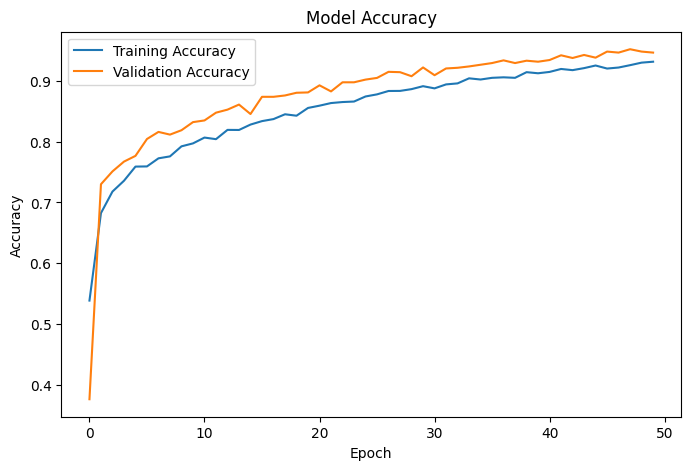

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

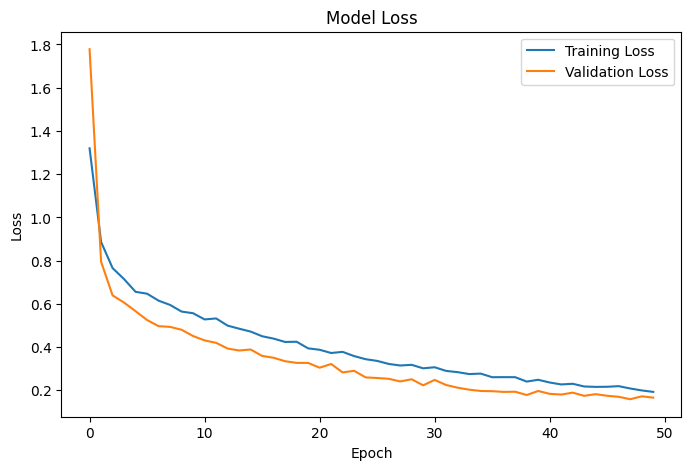

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [42]:
predictions = model.predict(X_test)

predictions = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.94      0.97      0.95       262
     boredom       0.67      0.75      0.71        16
        calm       0.75      0.97      0.85        77
     disgust       0.97      0.96      0.97       246
        fear       0.99      0.96      0.98       251
       happy       0.97      0.94      0.95       251
     neutral       0.95      0.91      0.93       214
         sad       0.97      0.96      0.96       249
    surprise       0.97      0.97      0.97       237

    accuracy                           0.95      1803
   macro avg       0.91      0.93      0.92      1803
weighted avg       0.96      0.95      0.95      1803



In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predictions)

print(cm)

[[254   1   2   1   0   4   0   0   0]
 [  0  12   0   0   0   0   4   0   0]
 [  0   0  75   0   0   0   0   2   0]
 [  5   0   1 237   0   2   0   0   1]
 [  1   0   1   5 241   1   1   1   0]
 [  6   1   0   0   1 235   1   1   6]
 [  1   4  13   0   0   0 195   1   0]
 [  2   0   4   1   1   0   3 238   0]
 [  1   0   4   0   0   0   1   2 229]]


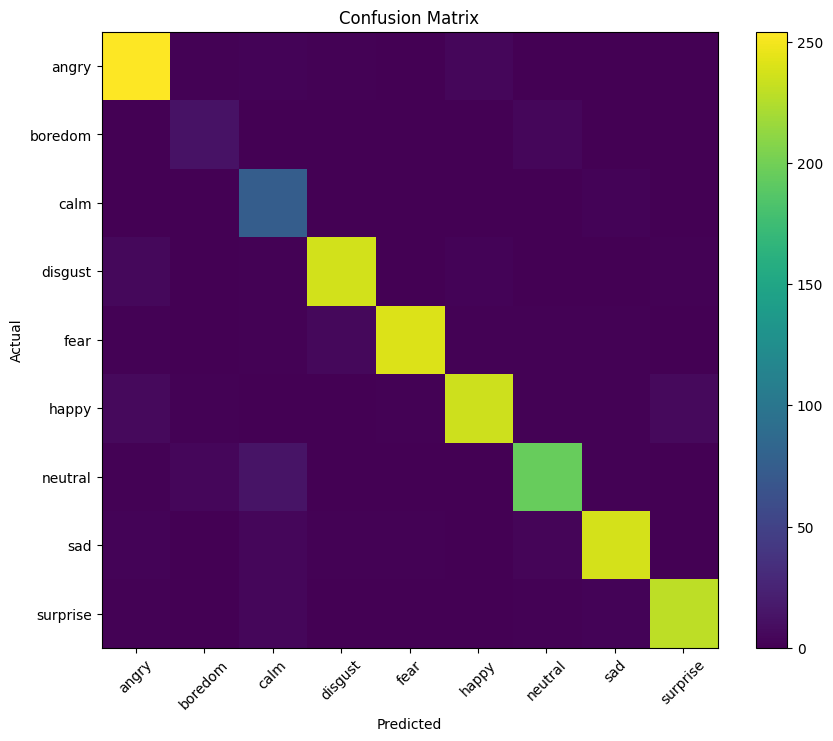

In [45]:
plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

ticks = np.arange(len(encoder.classes_))

plt.xticks(ticks, encoder.classes_, rotation=45)

plt.yticks(ticks, encoder.classes_)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [46]:
model.save("EmotionRecognitionModel.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [47]:
import pickle

with open("label_encoder.pkl","wb") as f:

    pickle.dump(encoder,f)

print("Encoder Saved")

Encoder Saved


In [48]:
with open("scaler.pkl","wb") as f:

    pickle.dump(scaler,f)

print("Scaler Saved")

Scaler Saved


In [49]:
from tensorflow.keras.models import load_model

loaded_model = load_model("EmotionRecognitionModel.keras")

print("Model Loaded")

Model Loaded


In [50]:
def predict_emotion(audio_file):

    signal, sr = librosa.load(audio_file, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=40
    )

    mfcc = np.mean(mfcc.T, axis=0)

    mfcc = scaler.transform([mfcc])

    mfcc = mfcc.reshape(1,40,1)

    prediction = loaded_model.predict(mfcc)

    emotion = encoder.inverse_transform(
        [np.argmax(prediction)]
    )[0]

    print("Predicted Emotion :", emotion)

In [54]:
predict_emotion("/content/03a02Fc.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
Predicted Emotion : happy


In [56]:
import IPython.display as ipd

ipd.Audio("/content/03a02Fc.wav")

In [57]:
print("="*50)

print("Speech Emotion Recognition Completed Successfully!")

print("="*50)

print("Model Accuracy :", accuracy)

print("Classes :", encoder.classes_)

print("="*50)

Speech Emotion Recognition Completed Successfully!
Model Accuracy : 0.9517470598220825
Classes : ['angry' 'boredom' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad'
 'surprise']
